In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import torch
print("GPU:", torch.cuda.is_available())

GPU: True


In [23]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

def get_vit_model(num_classes=102):
    # Recent weight
    weights = ViT_B_16_Weights.IMAGENET1K_V1
    model = vit_b_16(weights=weights)

    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    return model.to(device)

# ViT(224x224)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset
dataset_vit = datasets.ImageFolder(root=data_dir, transform=transform_vit)
train_loader_vit = DataLoader(Subset(dataset_vit, train_idx), batch_size=32, shuffle=True)
test_loader_vit = DataLoader(Subset(dataset_vit, test_idx), batch_size=32)

=== Method 3: Vision Transformer (ViT)  ===
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 238MB/s]


Epoch [1/5] complete
Epoch [2/5] complete
Epoch [3/5] complete
Epoch [4/5] complete
Epoch [5/5] complete
              precision    recall  f1-score   support

           0       0.75      0.67      0.71        70
           1       0.99      1.00      0.99        66
           2       1.00      0.98      0.99        66
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00       120
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00       120
           7       0.83      0.83      0.83         6
           8       1.00      0.83      0.91         6
           9       1.00      0.86      0.92         7
          10       1.00      1.00      1.00         8
          11       0.60      0.86      0.71         7
          12       0.83      1.00      0.91         5
          13       0.86      1.00      0.93        19
          14       1.00      0.73      0.85        15
          15       0.67      0

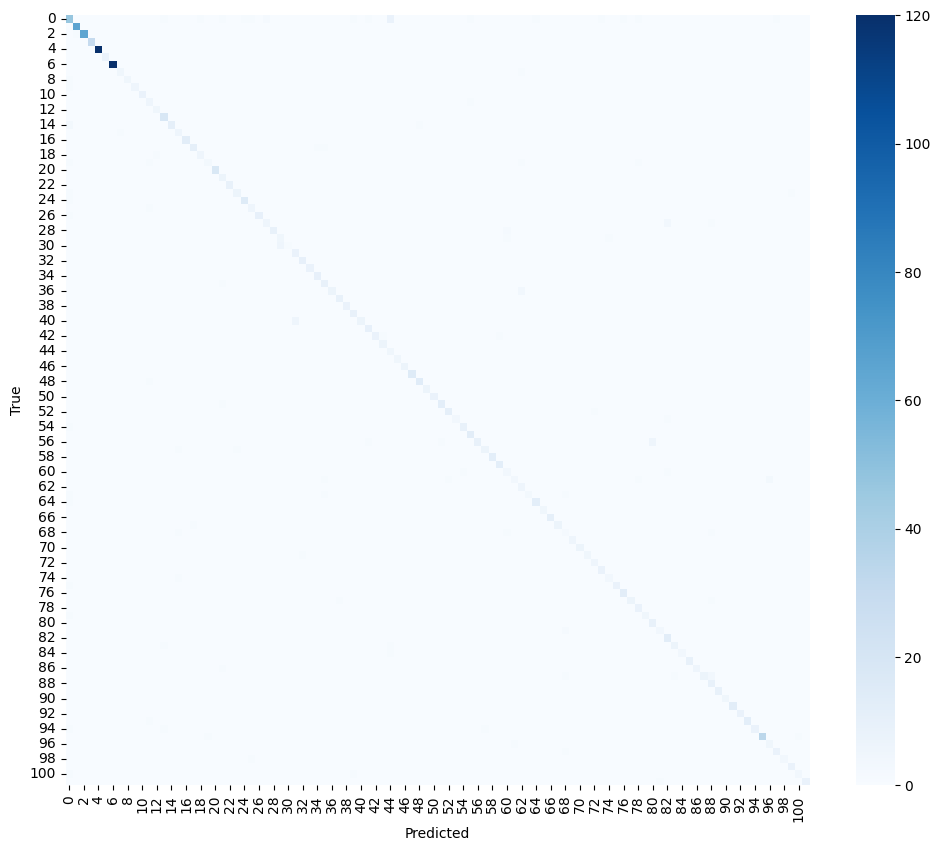

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch.optim as optim

def train_ablation_model(model, train_loader, optimizer, epochs=5):
    criterion = torch.nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch [{epoch+1}/{epochs}] complete")
    return model

def evaluate_and_plot(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Classification Report
    print(classification_report(all_labels, all_preds))

    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
print("=== Method 3: Vision Transformer (ViT)  ===")
model_vit = get_vit_model()
optimizer_vit = optim.Adam(model_vit.parameters(), lr=0.0001)

model_vit = train_ablation_model(model_vit, train_loader_vit, optimizer_vit, epochs=5)
evaluate_and_plot(model_vit, test_loader_vit)